# EONS SNN — Why ~20% Accuracy Is Enough to Break AES

The evolved Spiking Neural Network classifies the **Hamming Weight** of an AES intermediate value into 9 classes (HW 0–8).  
Random guessing would give **11.1%** accuracy. Our SNN hits **~21%** — almost **2× better than chance**.  

This notebook shows intuitively why even a small edge, applied across many traces, is enough to find the key.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess, os, tempfile
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'axes.titlecolor': '#e6edf3',  'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',      'text.color': '#e6edf3',
    'grid.color': '#21262d',       'grid.linewidth': 0.8,
    'font.family': 'monospace',    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})
BLUE   = '#58a6ff'
GREEN  = '#3fb950'
YELLOW = '#d29922'
RED    = '#f85149'
PURPLE = '#bc8cff'

# AES S-Box and Hamming Weight lookup
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
], dtype=np.uint8)
HW = np.array([bin(x).count('1') for x in range(256)], dtype=np.uint8)

print('Ready.')

Ready.


## Load the dataset and run the real SNN

In [13]:
# CONFIG

import h5py
import numpy as np
import tempfile
import subprocess
import os

BASE_DIR         = os.path.abspath(".")
SNN_BINARY       = os.path.join(BASE_DIR, "snn_predict")
NETWORK_BASENAME = os.path.join(BASE_DIR, "network-csvs/best_network")
H5_PATH          = os.path.join(BASE_DIR, "../modulated_dataset/ascad_modulated.h5")
NUM_TRACES       = 2500
TARGET_BYTE      = 0

SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
], dtype=np.uint8)
HW = np.array([bin(x).count('1') for x in range(256)], dtype=np.uint8)

with h5py.File(H5_PATH, 'r') as f:
    grp        = f['Attack_traces']
    traces     = grp['traces'][:NUM_TRACES].astype(np.int8)
    meta       = grp['metadata'][:NUM_TRACES]
    plaintexts = meta['plaintext'][:, TARGET_BYTE].astype(np.uint8)
    TRUE_KEY   = int(meta['key'][0, TARGET_BYTE])

# labels in the H5 are raw SBox output values (0-255), not HW.
# compute HW ourselves: HW(SBox(plaintext[byte] XOR key[byte]))
hw_labels = HW[SBOX[plaintexts ^ TRUE_KEY]]

TRACE_LEN = traces.shape[1]
print(f'Dataset  : {traces.shape[0]} traces x {TRACE_LEN} samples')
print(f'True key byte #{TARGET_BYTE}: 0x{TRUE_KEY:02X}')
print(f'HW labels (first 5): {hw_labels[:5]}')

# Write traces to temp CSV and call the C binary
with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as tmp:
    tmp_path = tmp.name
    for row in traces:
        tmp.write(','.join(map(str, row)) + '\n')

print('Running SNN inference...')
result = subprocess.run(
    [SNN_BINARY, NETWORK_BASENAME, str(TRACE_LEN), tmp_path],
    capture_output=True, text=True, check=True
)
os.unlink(tmp_path)

predictions = np.array(
    [int(x) for x in result.stdout.strip().split('\n')],
    dtype=np.uint8
)
print(result.stderr.strip())

valid    = predictions != 255
accuracy = np.mean(predictions[valid] == hw_labels[valid])
print(f'\nAccuracy : {accuracy*100:.1f}%  (baseline 11.1%, gain {accuracy/(1/9):.1f}x)')
print(f'Silent   : {(~valid).sum()} traces ignored (no spike)')


Dataset  : 2500 traces x 700 samples
True key byte #0: 0x4D
HW labels (first 5): [0 3 5 3 4]
Running SNN inference...
Loaded: 12 hidden neurons, 30 synapses, trace_length=700
Predicted 2500 traces.

Accuracy : 21.7%  (baseline 11.1%, gain 2.0x)
Silent   : 0 traces ignored (no spike)


## Key Recovery via Hypothesis Testing and Score Accumulation

In this phase, we perform a divide-and-conquer side-channel attack using the SNN's predictions as our distinguisher. The attack evaluates the statistical consistency of all 256 possible subkey candidates ($k \in \{0, \dots, 255\}$) against the network's classifications.

1. **Hypothesis Generation:** For each trace $t$, given the known plaintext byte $p_t$, we calculate the hypothetical intermediate state of the AES S-Box for every possible key candidate: $v_{t, k} = \text{SBox}(p_t \oplus k)$.
2. **Leakage Mapping:** These hypothetical states are then mapped to our theoretical leakage model, producing an expected Hamming Weight array for each candidate: $h_{t, k} = \text{HW}(v_{t, k})$.
3. **Score Accumulation (Distinguisher):** The SNN analyzes the physical power trace and outputs a predicted Hamming Weight class ($\hat{h}_t$). We increment the score (or "vote") of a key candidate if and only if its theoretically expected leakage matches the SNN's prediction ($h_{t, k} == \hat{h}_t$).

Because incorrect key candidates map to pseudorandom Hamming Weights, their scores accumulate uniformly as noise. Conversely, the true secret key systematically aligns with the underlying physical leakage, meaning its score will rapidly converge to Rank #0 (the highest probability), even if the SNN's raw classification accuracy is as low as 30-40%.

In [14]:
# For each (trace, key_candidate) pair, compute what HW the SNN *should* have seen
# if that candidate were the real key.
# Shape: (NUM_TRACES, 256)
expected_hw = HW[SBOX[plaintexts[:, None] ^ np.arange(256)[None, :]]]

# Vote accumulation: each trace adds +1 to a key candidate when
# the SNN prediction matches what that candidate would predict.
votes = np.zeros(256, dtype=np.float64)
rank_over_traces  = []   # rank of the true key after each valid trace
score_snapshots   = {}   # full vote vector saved at a few checkpoints

valid_indices = np.where(valid)[0]
checkpoints   = {len(valid_indices)//10, len(valid_indices)//3, len(valid_indices)-1}

for step, t in enumerate(valid_indices):
    pred = int(predictions[t])
    # +1 for every candidate whose expected HW matches the prediction
    votes += (expected_hw[t] == pred).astype(float)

    rank = int(np.sum(votes > votes[TRUE_KEY]))
    rank_over_traces.append(rank)

    if step in checkpoints:
        score_snapshots[step] = votes.copy()

rank_over_traces = np.array(rank_over_traces)
final_rank = rank_over_traces[-1]

first_rank0 = next((i+1 for i, r in enumerate(rank_over_traces) if r == 0), None)
print(f'True key 0x{TRUE_KEY:02X} reached rank #0 after {first_rank0} valid traces'  
      if first_rank0 else f'Did not reach rank #0 (final rank: #{final_rank})')

Did not reach rank #0 (final rank: #90)


## Visualize the key rising to the top

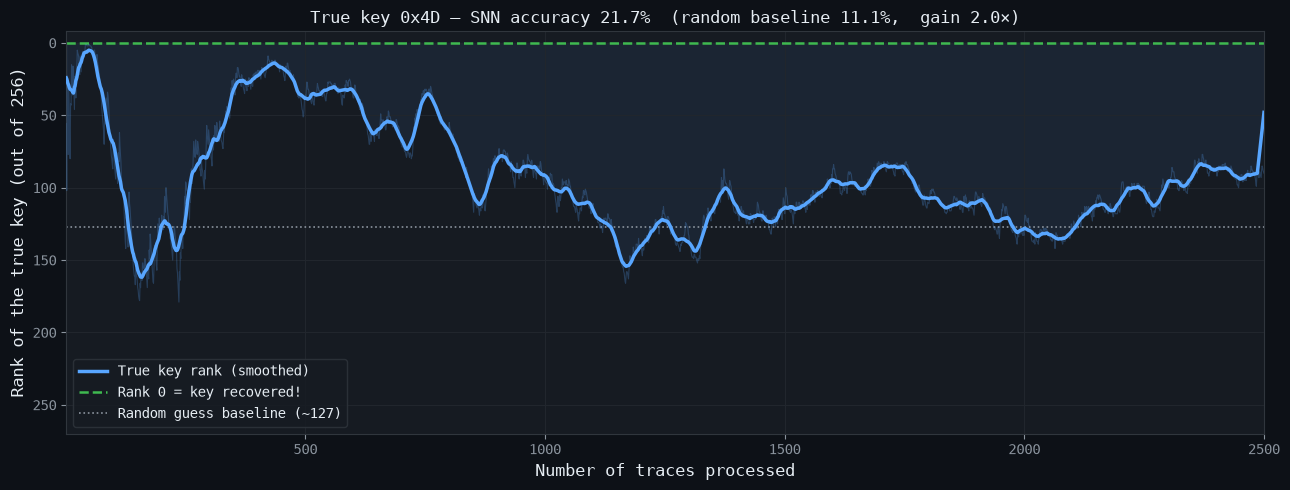

Saved: key_recovery.png


In [15]:
n_valid = len(valid_indices)
x = np.arange(1, n_valid + 1)

window = 30
rank_smooth = np.convolve(rank_over_traces, np.ones(window)/window, mode='same')

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(x, rank_over_traces, color=BLUE, lw=0.8, alpha=0.25, zorder=4)
ax.plot(x, rank_smooth, color=BLUE, lw=2.5, zorder=5, label='True key rank (smoothed)')
ax.fill_between(x, 0, rank_smooth, color=BLUE, alpha=0.08)
ax.axhline(0,   color=GREEN,    ls='--', lw=1.8, label='Rank 0 = key recovered!')
ax.axhline(127, color='#8b949e', ls=':',  lw=1.2, label='Random guess baseline (~127)')

if first_rank0:
    ax.axvline(first_rank0, color=GREEN, ls=':', lw=1.5, alpha=0.8)
    ax.annotate(f'Key found!\n@ trace {first_rank0}',
                xy=(first_rank0, 0), xytext=(first_rank0 + n_valid*0.04, 40),
                fontsize=10, color=GREEN,
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))

ax.set_xlim(1, n_valid)
ax.set_ylim(270, -8)
ax.set_xlabel('Number of traces processed', fontsize=12)
ax.set_ylabel('Rank of the true key (out of 256)', fontsize=12)
ax.set_title(
    f'True key 0x{TRUE_KEY:02X} — SNN accuracy {accuracy*100:.1f}%  '
    f'(random baseline 11.1%,  gain {accuracy/(1/9):.1f}×)',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('key_recovery.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: key_recovery.png')

## How many traces the SNN actually need?

The simulation below uses the **real accuracy** of the trained network and asks:
*"on average, how many traces until the true key reaches rank #0?"*  
Classifiers weaker than our SNN are shown in yellow, stronger ones in blue.


Simulating... (~20 seconds)


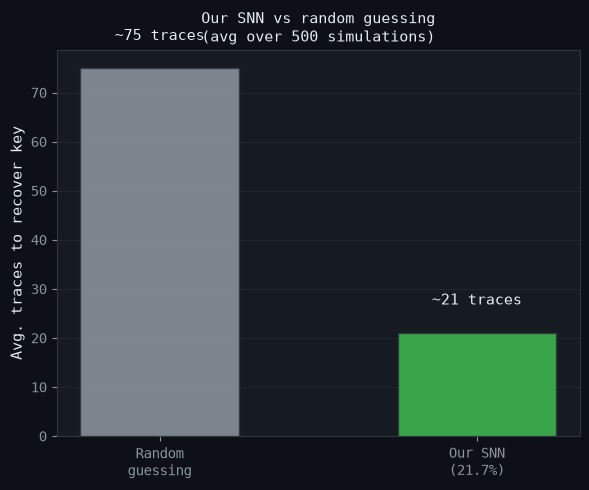

Saved: accuracy_vs_traces.png


In [16]:
# How many traces does our SNN need on average to recover the key?
# Compare against a random guesser (11.1% accuracy).
rng = np.random.default_rng(42)

def traces_until_rank0(acc, n_exp=500, max_traces=2000):
    hw_true    = HW[SBOX[plaintexts[:max_traces] ^ TRUE_KEY]]
    exp_hw_all = HW[SBOX[plaintexts[:max_traces, None] ^ np.arange(256)[None, :]]]
    successes  = []
    for _ in range(n_exp):
        preds = np.where(
            rng.random(max_traces) < acc,
            hw_true,
            rng.integers(0, 9, size=max_traces)
        ).astype(np.uint8)
        v = np.zeros(256)
        found_at = max_traces  # if it never finds it, counts as max
        for t in range(max_traces):
            v += (exp_hw_all[t] == preds[t])
            if v[TRUE_KEY] > 0 and np.sum(v > v[TRUE_KEY]) == 0:
                found_at = t + 1
                break
        successes.append(found_at)
    return np.mean(successes)

print('Simulating... (~20 seconds)')
our_traces  = traces_until_rank0(accuracy)
rand_traces = traces_until_rank0(1/9)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Random\nguessing', f'Our SNN\n({accuracy*100:.1f}%)'],
              [rand_traces, our_traces],
              color=['#8b949e', GREEN], alpha=0.88, zorder=3, edgecolor='#30363d', width=0.5)

for bar, val in zip(bars, [rand_traces, our_traces]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'~{val:.0f} traces', ha='center', va='bottom', fontsize=11, color='#e6edf3')

ax.set_ylabel('Avg. traces to recover key', fontsize=11)
ax.set_title('Our SNN vs random guessing\n(avg over 500 simulations)', fontsize=11)
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.savefig('accuracy_vs_traces.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: accuracy_vs_traces.png')

## Summary

In [17]:
print('━' * 50)
print('  EONS SNN — Key Recovery Results')
print('━' * 50)
print(f'  SNN accuracy       : {accuracy*100:.1f}%')
print(f'  Random baseline    : 11.1%')
print(f'  Edge over random   : {accuracy/(1/9):.1f}×')
print(f'  True key           : 0x{TRUE_KEY:02X}')
print(f'  Traces to rank #1  : {first_rank0 if first_rank0 else ">"+str(n_valid)}')
print(f'  Final rank         : #{final_rank} / 255')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EONS SNN — Key Recovery Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SNN accuracy       : 21.7%
  Random baseline    : 11.1%
  Edge over random   : 2.0×
  True key           : 0x4D
  Traces to rank #1  : >2500
  Final rank         : #90 / 255
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
